In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [25]:
def plot_hyperparameter_heatmaps(
    csv_path,
    metric,
    method,
    output_path=None,
    lower_is_better=False,
):
    """
    Generate hyperparameter heatmaps for one method and one metric.

    Expected CSV columns:
        method, metric, poison_ratio, learning_rate, epochs, value
    """

    df = pd.read_csv(csv_path)

    required_cols = {
        "method",
        "metric",
        "poison_ratio",
        "learning_rate",
        "epochs",
        "value",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"CSV is missing required columns: {missing}")

    # Normalize types
    df["method"] = df["method"].astype(str)
    df["metric"] = df["metric"].astype(str)
    df["poison_ratio"] = df["poison_ratio"].astype(float)
    df["learning_rate"] = df["learning_rate"].astype(float)
    df["epochs"] = df["epochs"].astype(int)
    df["value"] = df["value"].astype(float)

    sub = df[(df["method"] == method) & (df["metric"] == metric)].copy()

    if sub.empty:
        raise ValueError(f"No rows found for method={method}, metric={metric}")

    poison_ratios = sorted(sub["poison_ratio"].unique())
    learning_rates = sorted(sub["learning_rate"].unique())
    epochs = sorted(sub["epochs"].unique())

    vmin = sub["value"].min()
    vmax = sub["value"].max()

    n_panels = len(poison_ratios)

    # Use constrained_layout so matplotlib automatically leaves room
    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=(5 * n_panels, 4),
        squeeze=False,
        constrained_layout=True,
    )
    axes = axes[0]

    im = None

    for ax, pr in zip(axes, poison_ratios):
        panel = sub[sub["poison_ratio"] == pr]

        heatmap_data = (
            panel.pivot_table(
                index="learning_rate",
                columns="epochs",
                values="value",
                aggfunc="mean",
            )
            .reindex(index=learning_rates, columns=epochs)
        )

        matrix = heatmap_data.to_numpy()

        im = ax.imshow(
            matrix,
            aspect="auto",
            vmin=vmin,
            vmax=vmax,
            cmap="viridis",
        )

        ax.set_title(f"Poison ratio = {pr:.0%}")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Learning rate")

        ax.set_xticks(np.arange(len(epochs)))
        ax.set_xticklabels(epochs)

        ax.set_yticks(np.arange(len(learning_rates)))
        ax.set_yticklabels([f"{lr:g}" for lr in learning_rates])

        # Annotate cells
        for i in range(len(learning_rates)):
            for j in range(len(epochs)):
                value = matrix[i, j]
                if not np.isnan(value):
                    ax.text(
                        j,
                        i,
                        f"{value:.1f}",
                        ha="center",
                        va="center",
                        color="black",
                    )

    direction = "lower is better" if lower_is_better else "higher is better"
    fig.suptitle(f"{method} - {metric} ({direction})", fontsize=16)

    # Create ONE shared colorbar for all subplots, outside the axes
    cbar = fig.colorbar(
        im,
        ax=axes,
        location="right",
        shrink=0.9,
        pad=0.02,
    )
    cbar.set_label(metric)

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

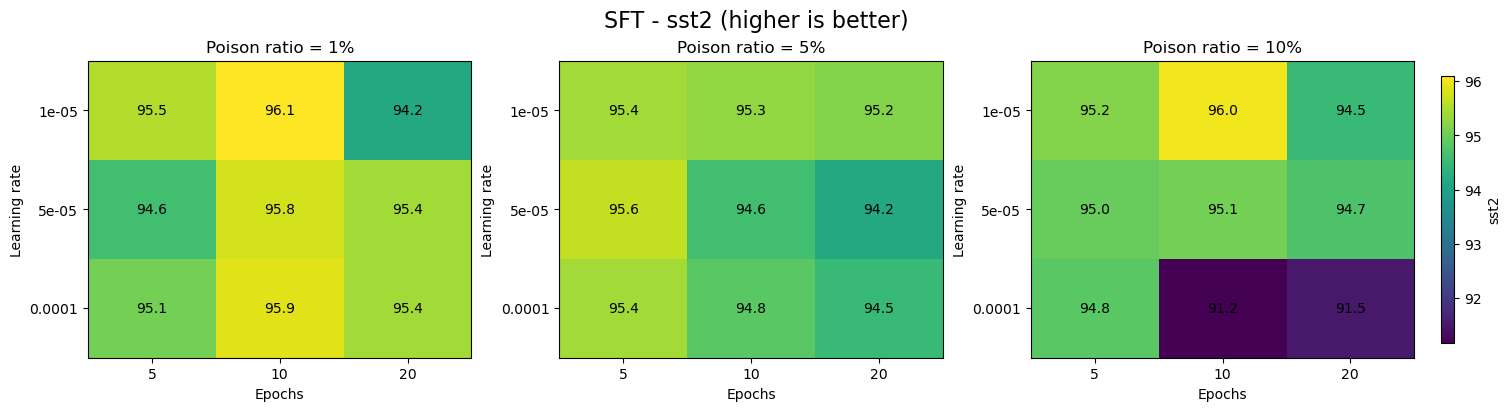

In [26]:
plot_hyperparameter_heatmaps(
    csv_path="sft_utility_sst2_only.csv",
    metric="sst2",
    method="SFT",
    output_path="sft_sst2_heatmap.png",
    lower_is_better=False,
)

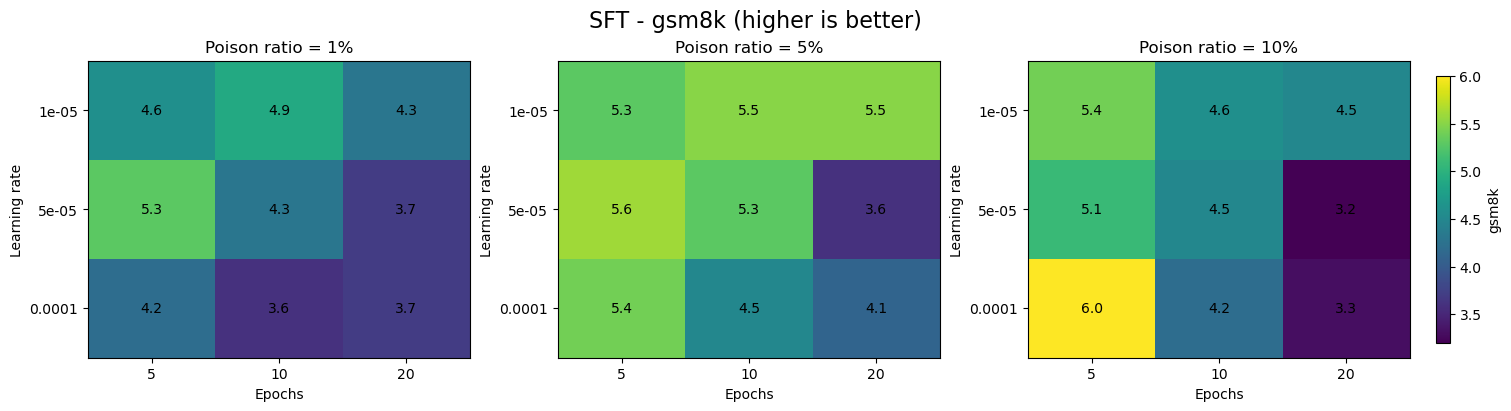

In [27]:
plot_hyperparameter_heatmaps(
    csv_path="sft_utility_gsm8k_only.csv",
    metric="gsm8k",
    method="SFT",
    output_path="sft_gsm8k_heatmap.png",
    lower_is_better=False,
)

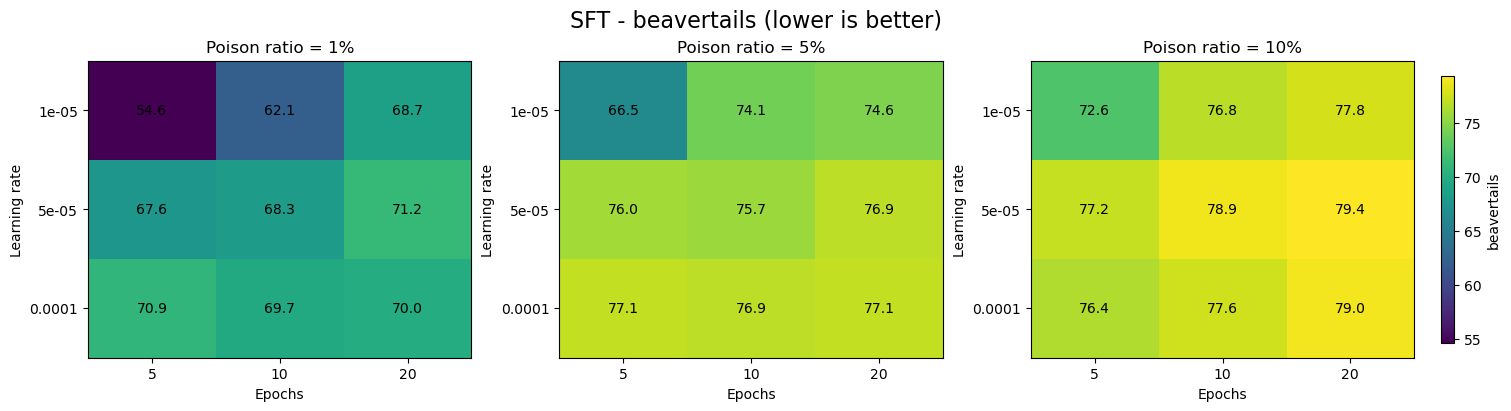

In [28]:
plot_hyperparameter_heatmaps(
    csv_path="sft_harmful_beavertails_only.csv",
    metric="beavertails",
    method="SFT",
    output_path="sft_beavertails_heatmap.png",
    lower_is_better=True,
)

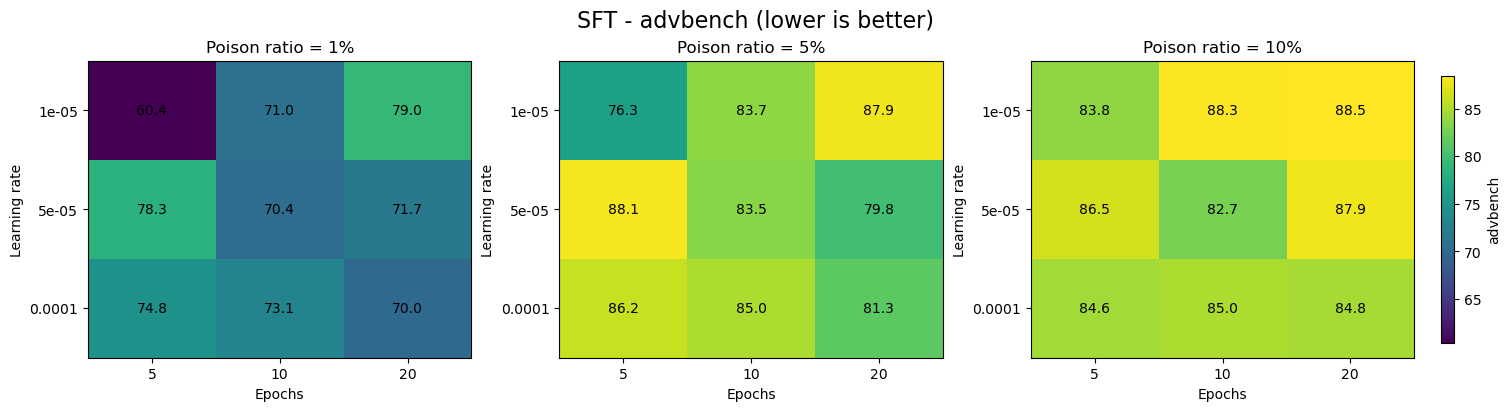

In [29]:
plot_hyperparameter_heatmaps(
    csv_path="sft_harmful_advbench_only.csv",
    metric="advbench",
    method="SFT",
    output_path="sft_advbench_heatmap.png",
    lower_is_better=True,
)

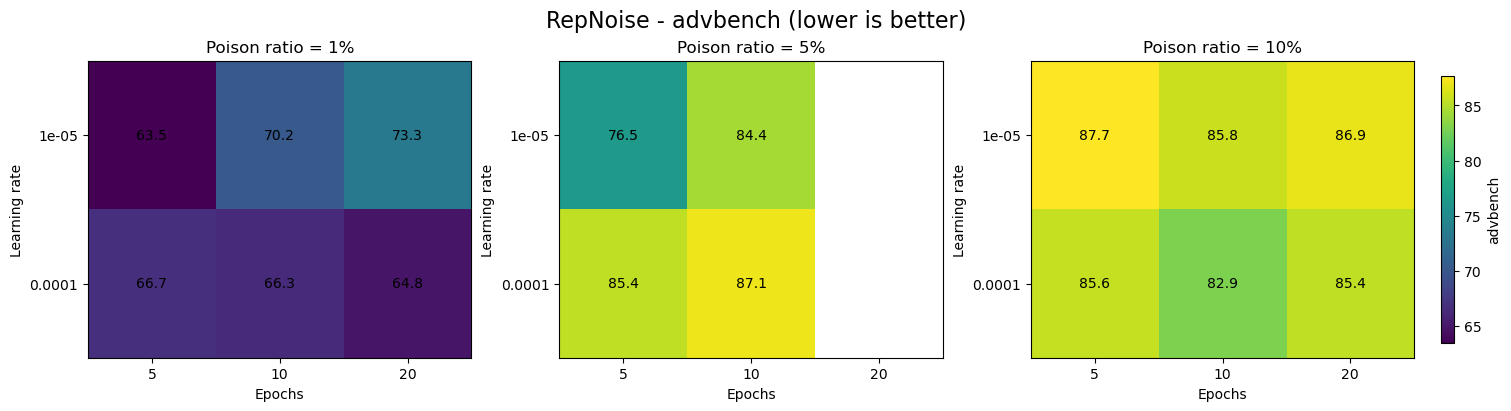

In [30]:
plot_hyperparameter_heatmaps(
    csv_path="repnoise_advbench_only.csv",
    metric="advbench",
    method="RepNoise",
    output_path="repnoise_advbench_heatmap.png",
    lower_is_better=True,
)

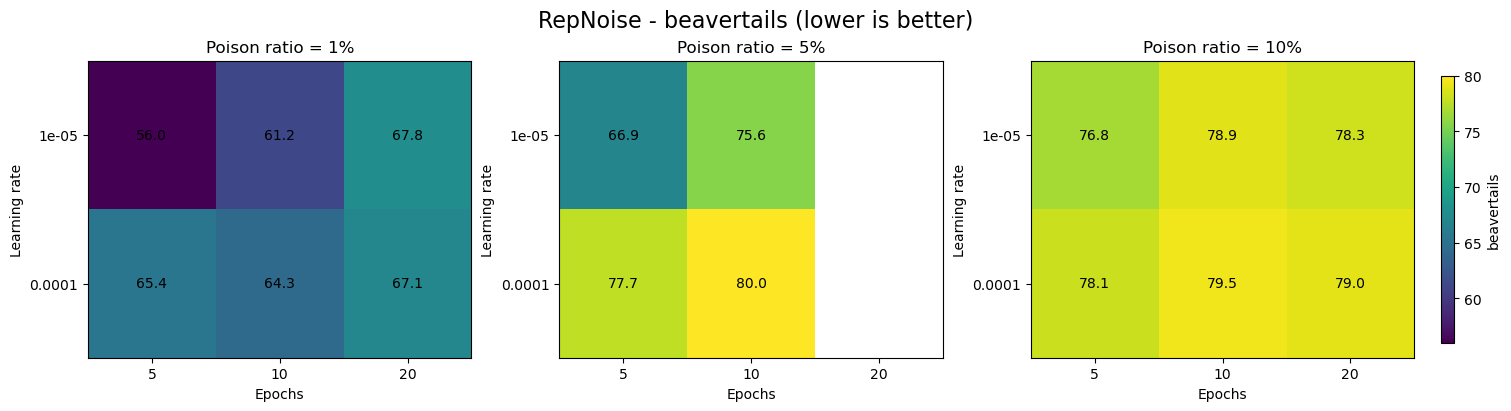

In [31]:
plot_hyperparameter_heatmaps(
    csv_path="repnoise_beavertails_only.csv",
    metric="beavertails",
    method="RepNoise",
    output_path="repnoise_beavertails_heatmap.png",
    lower_is_better=True,
)

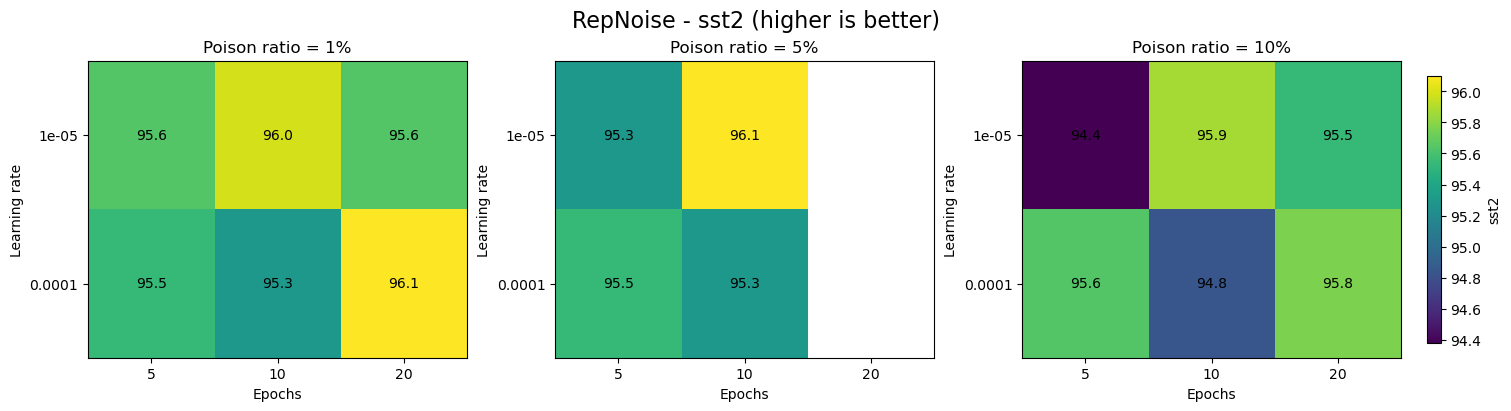

In [32]:
plot_hyperparameter_heatmaps(
    csv_path="repnoise_sst2_only.csv",
    metric="sst2",
    method="RepNoise",
    output_path="repnoise_sst2_heatmap.png",
    lower_is_better=False,
)

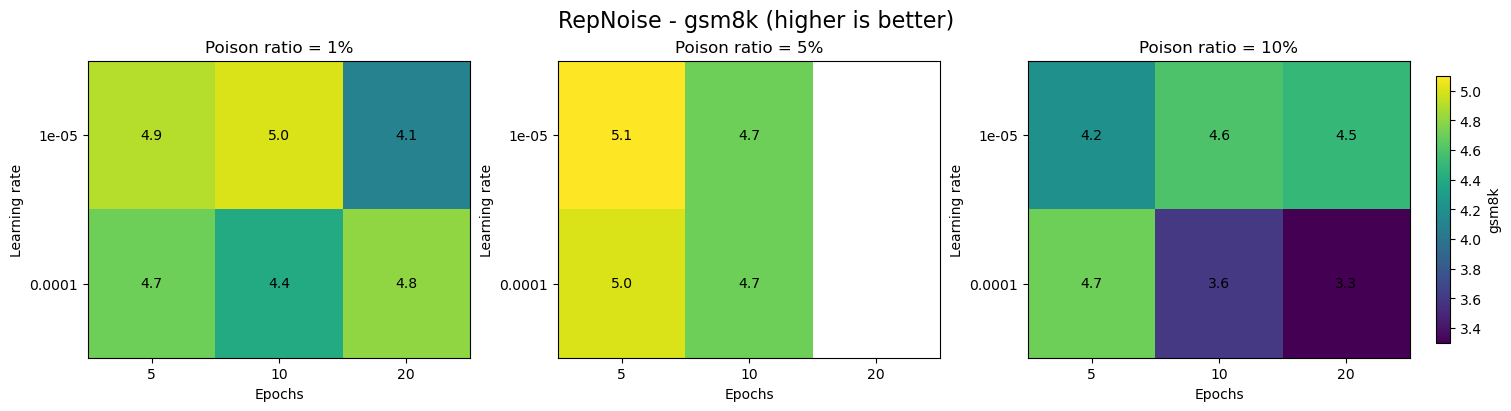

In [33]:
plot_hyperparameter_heatmaps(
    csv_path="repnoise_gsm8k_only.csv",
    metric="gsm8k",
    method="RepNoise",
    output_path="repnoise_gsm8k_heatmap.png",
    lower_is_better=False,
)

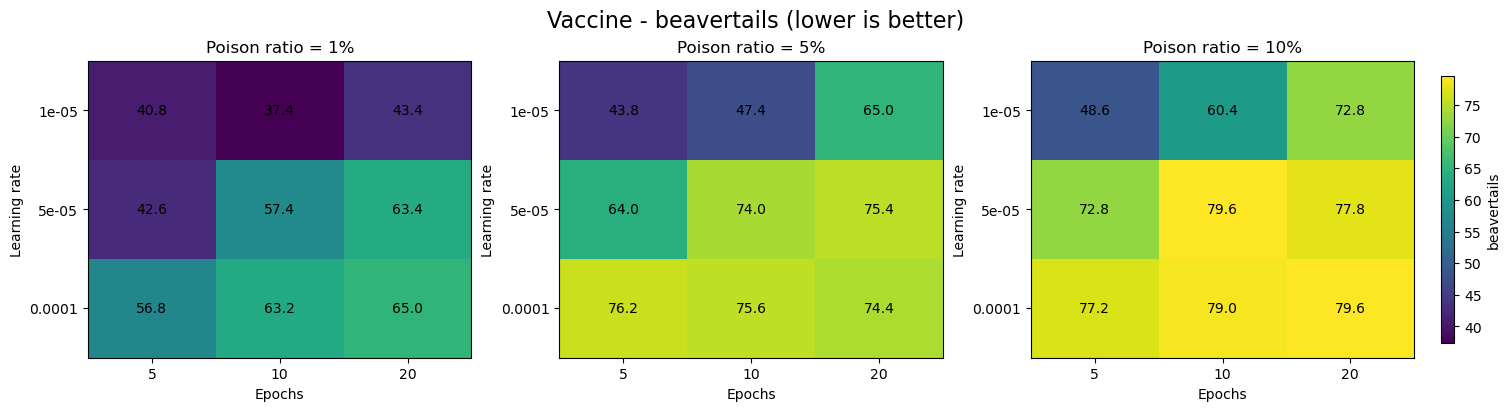

In [34]:
plot_hyperparameter_heatmaps(
    csv_path="vaccine_beavertails_only.csv",
    metric="beavertails",
    method="Vaccine",
    output_path="vaccine_beavertails_heatmap.png",
    lower_is_better=True,
)

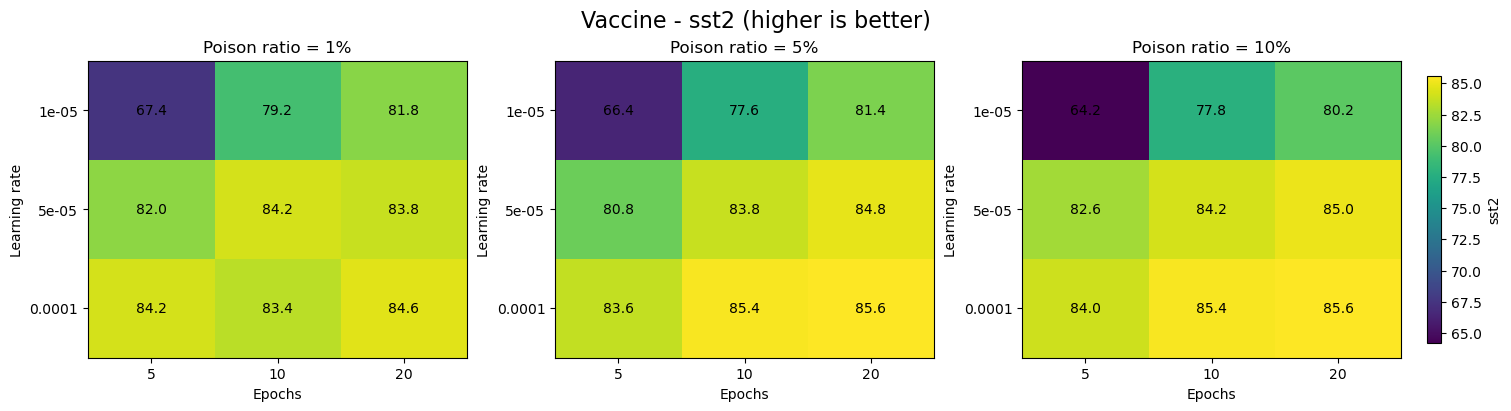

In [35]:
plot_hyperparameter_heatmaps(
    csv_path="vaccine_sst2_only.csv",
    metric="sst2",
    method="Vaccine",
    output_path="vaccine_sst2_heatmap.png",
    lower_is_better=False,
)

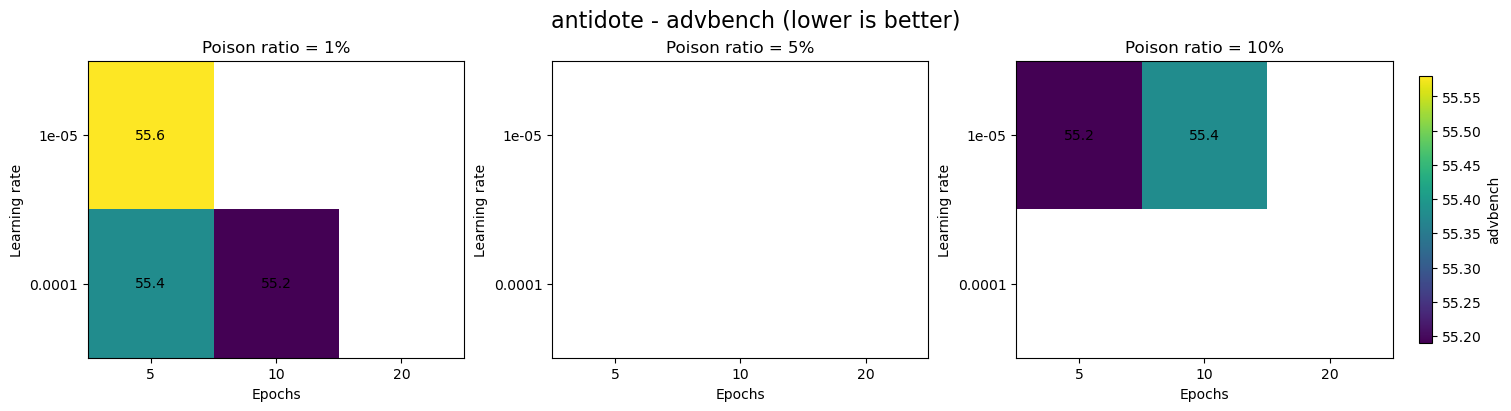

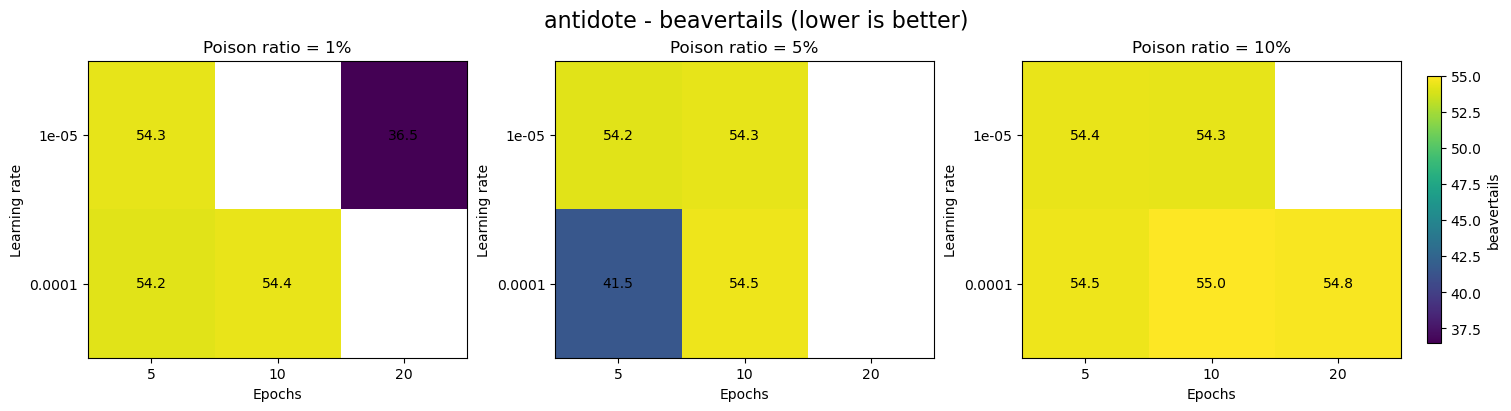

In [38]:
plot_hyperparameter_heatmaps(
    csv_path="antidote_13runs_beavertails.csv",
    metric="beavertails",
    method="antidote",
    output_path="antidote_beavertails_heatmap.png",
    lower_is_better=True,
)

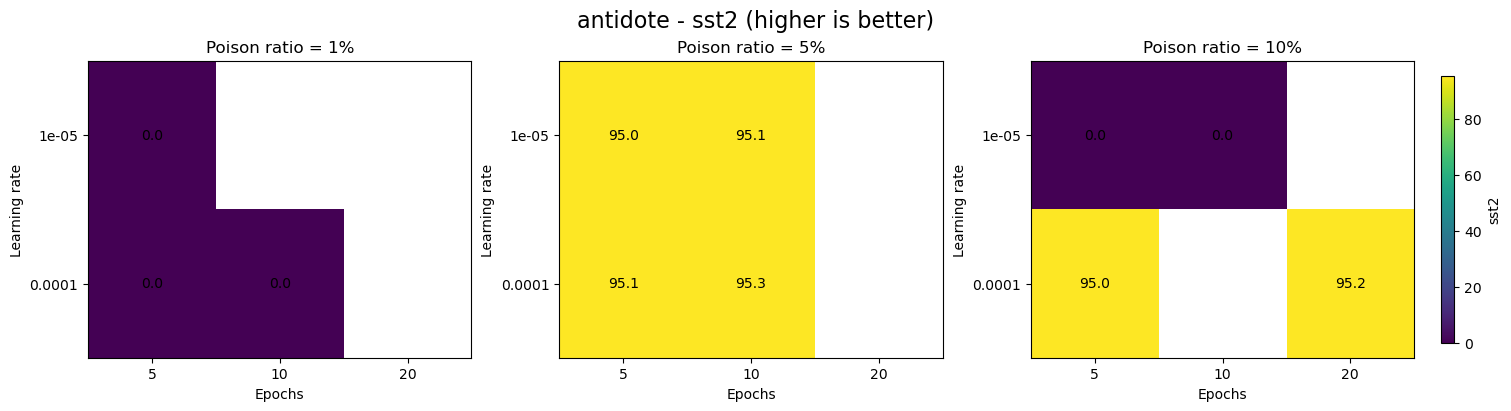

In [40]:
plot_hyperparameter_heatmaps(
    csv_path="antidote_13runs_sst2.csv",
    metric="sst2",
    method="antidote",
    output_path="antidote_sst2_heatmap.png",
    lower_is_better=False,
)

In [48]:
def load_and_merge_method(method_name, sst2_csv, beavertails_csv):
    sst2 = pd.read_csv(sst2_csv)
    beaver = pd.read_csv(beavertails_csv)

    # Keep only actual numeric values
    sst2["value"] = pd.to_numeric(sst2["value"], errors="coerce")
    beaver["value"] = pd.to_numeric(beaver["value"], errors="coerce")

    sst2 = sst2.dropna(subset=["value"]).copy()
    beaver = beaver.dropna(subset=["value"]).copy()

    sst2 = sst2.rename(columns={"value": "sst2"})
    beaver = beaver.rename(columns={"value": "beavertails"})

    merge_cols = ["method", "poison_ratio", "learning_rate", "epochs"]

    merged = pd.merge(
        sst2[merge_cols + ["sst2"]],
        beaver[merge_cols + ["beavertails"]],
        on=merge_cols,
        how="inner",
    )

    # Normalize method name
    merged["method"] = method_name

    # Normalize numeric columns
    merged["poison_ratio"] = merged["poison_ratio"].astype(float)
    merged["learning_rate"] = merged["learning_rate"].astype(float)
    merged["epochs"] = merged["epochs"].astype(int)

    return merged

In [49]:
method_files = {
    "SFT": {
        "sst2": "sft_utility_sst2_only.csv",
        "beavertails": "sft_harmful_beavertails_only.csv",
    },
    "RepNoise": {
        "sst2": "repnoise_sst2_only.csv",
        "beavertails": "repnoise_beavertails_only.csv",
    },
    "Vaccine": {
        "sst2": "vaccine_sst2_only.csv",
        "beavertails": "vaccine_beavertails_only.csv",
    },
    "Antidote": {
        "sst2": "antidote_13runs_sst2.csv",
        "beavertails": "antidote_13runs_beavertails.csv",
    },
}

all_dfs = []
for method_name, paths in method_files.items():
    all_dfs.append(
        load_and_merge_method(
            method_name,
            paths["sst2"],
            paths["beavertails"],
        )
    )

plot_df = pd.concat(all_dfs, ignore_index=True)

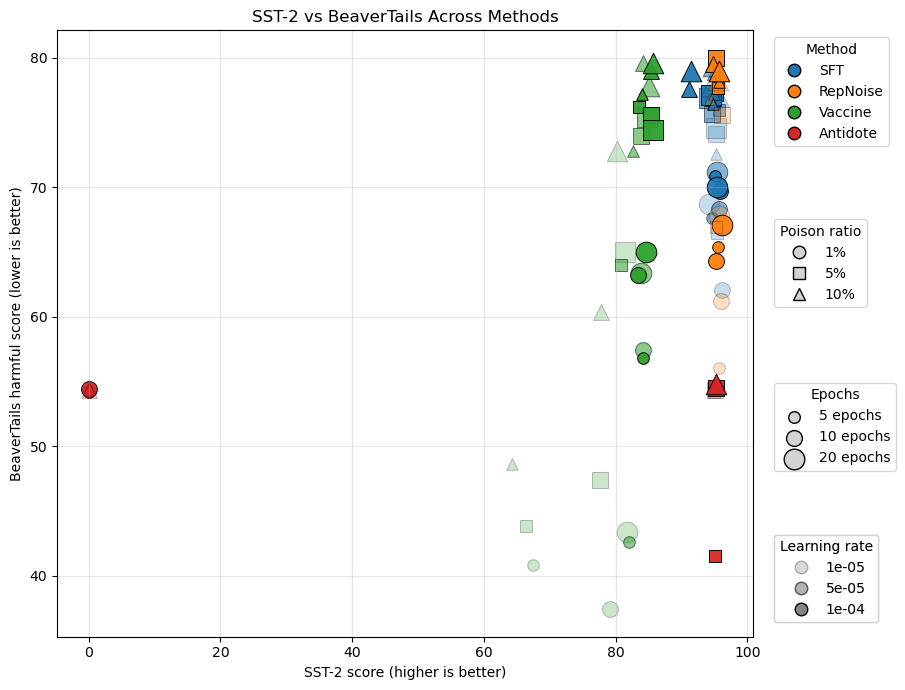

In [59]:
# Color = method
method_colors = {
    "SFT": "tab:blue",
    "RepNoise": "tab:orange",
    "Vaccine": "tab:green",
    "Antidote": "tab:red",
}

# Shape = poison ratio
poison_markers = {
    0.01: "o",   # circle
    0.05: "s",   # square
    0.10: "^",   # triangle
}

# Size = epochs
epoch_sizes = {
    5: 70,
    10: 130,
    20: 220,
}

# Optional: alpha = learning rate
# Higher learning rate appears more opaque
lr_alpha = {
    1e-5: 0.25,
    5e-5: 0.55,
    1e-4: 0.95,
}


fig, ax = plt.subplots(figsize=(10, 7))

for _, row in plot_df.iterrows():
    method = row["method"]
    poison_ratio = row["poison_ratio"]
    epochs = row["epochs"]
    lr = row["learning_rate"]

    ax.scatter(
        row["sst2"],
        row["beavertails"],
        color=method_colors.get(method, "gray"),
        marker=poison_markers.get(poison_ratio, "o"),
        s=epoch_sizes.get(epochs, 100),
        alpha=lr_alpha.get(lr, 0.8),
        edgecolors="black",
        linewidths=0.7,
    )

    # Legend 1: method color
method_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=method,
        markerfacecolor=color,
        markeredgecolor="black",
        markersize=9,
    )
    for method, color in method_colors.items()
]

legend1 = ax.legend(
    handles=method_handles,
    title="Method",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
)
ax.add_artist(legend1)


# Legend 2: poison ratio shape
poison_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        color="w",
        label=f"{ratio:.0%}",
        markerfacecolor="lightgray",
        markeredgecolor="black",
        markersize=9,
    )
    for ratio, marker in poison_markers.items()
]

legend2 = ax.legend(
    handles=poison_handles,
    title="Poison ratio",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.70),
)
ax.add_artist(legend2)


# Legend 3: epoch size
epoch_handles = [
    plt.scatter(
        [],
        [],
        s=size,
        color="lightgray",
        edgecolors="black",
        label=f"{epoch} epochs",
    )
    for epoch, size in epoch_sizes.items()
]

legend3 = ax.legend(
    handles=epoch_handles,
    title="Epochs",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.43),
)
ax.add_artist(legend3)

lr_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=f"{lr:.0e}",
        markerfacecolor="gray",
        markeredgecolor="black",
        alpha=alpha,
        markersize=9,
    )
    for lr, alpha in lr_alpha.items()
]

legend4 = ax.legend(
    handles=lr_handles,
    title="Learning rate",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.18),
)
ax.add_artist(legend4)

ax.set_title("SST-2 vs BeaverTails Across Methods")
ax.set_xlabel("SST-2 score (higher is better)")
ax.set_ylabel("BeaverTails harmful score (lower is better)")

ax.grid(True, alpha=0.3)

# Leave room on right for legends
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

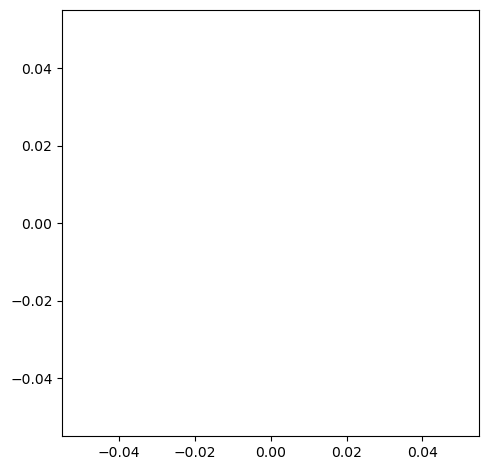

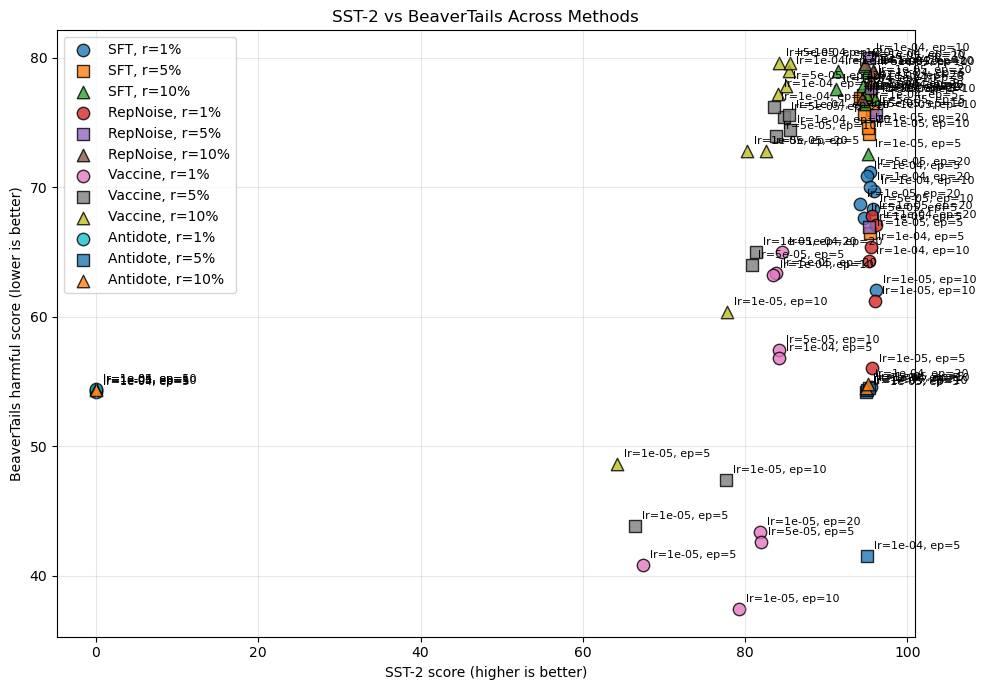

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

# Different marker per poison ratio
marker_map = {
    0.01: "o",
    0.05: "s",
    0.10: "^",
}

for method_name in plot_df["method"].unique():
    method_df = plot_df[plot_df["method"] == method_name]

    for poison_ratio in sorted(method_df["poison_ratio"].unique()):
        subset = method_df[method_df["poison_ratio"] == poison_ratio]

        ax.scatter(
            subset["sst2"],
            subset["beavertails"],
            label=f"{method_name}, r={poison_ratio:.0%}",
            marker=marker_map.get(poison_ratio, "o"),
            s=80,
            alpha=0.8,
            edgecolors="black",
        )

        # Optional annotations
        for _, row in subset.iterrows():
            label = f"lr={row['learning_rate']:.0e}, ep={int(row['epochs'])}"
            ax.annotate(
                label,
                (row["sst2"], row["beavertails"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8,
            )

ax.set_title("SST-2 vs BeaverTails Across Methods")
ax.set_xlabel("SST-2 score (higher is better)")
ax.set_ylabel("BeaverTails harmful score (lower is better)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()